# Electrical Transformer Temperature Prediction (ETDataset)

The ETDataset (Electricity Transformer Dataset) provides long-term data collected from electrical transformer substations. Predicting Oil Temperature (OT) is crucial, as it is a key indicator of transformer health and extreme load. Accurate forecasts allow for the prevention of overheating, equipment depreciation, and optimization of electrical distribution.

In this project, we modeled the problem as a **Multivariate Regression** based on sliding windows. To capture short-, medium-, and long-term dependencies, we implemented and compared five state-of-the-art Deep Learning architectures.
The benchmark evaluates the Mean Squared Error (MSE), Mean Absolute Error (MAE), and Run Time of each model.

---
## 1. Importing Libraries and Configuring the Environment

In [10]:
import pandas as pd
import numpy as np
import os
import math
import time
import warnings
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Optuna for Hyperparameter Optimization
import optuna

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Device Configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

Using device: cuda


---
## 2. Data Ingestion (ETTh1)
We automatically download the **ETTh1** variant (hourly resolution) from the official repository to ensure notebook reproducibility.

In [11]:
data_path = 'ETTh1.csv'
url = 'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv'

if not os.path.exists(data_path):
    print("Downloading ETTh1 dataset...")
    urllib.request.urlretrieve(url, data_path)
    print("Download complete.")

# Load the data
data = pd.read_csv(data_path)
print(f"Dimensions of the dataset ETTh1: {data.shape}")
data.head()

Dimensions of the dataset ETTh1: (17420, 8)


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


---
## 3. Exploratory Data Analysis (EDA)
We visually inspect the target time series (`OT`) and check for correlations.

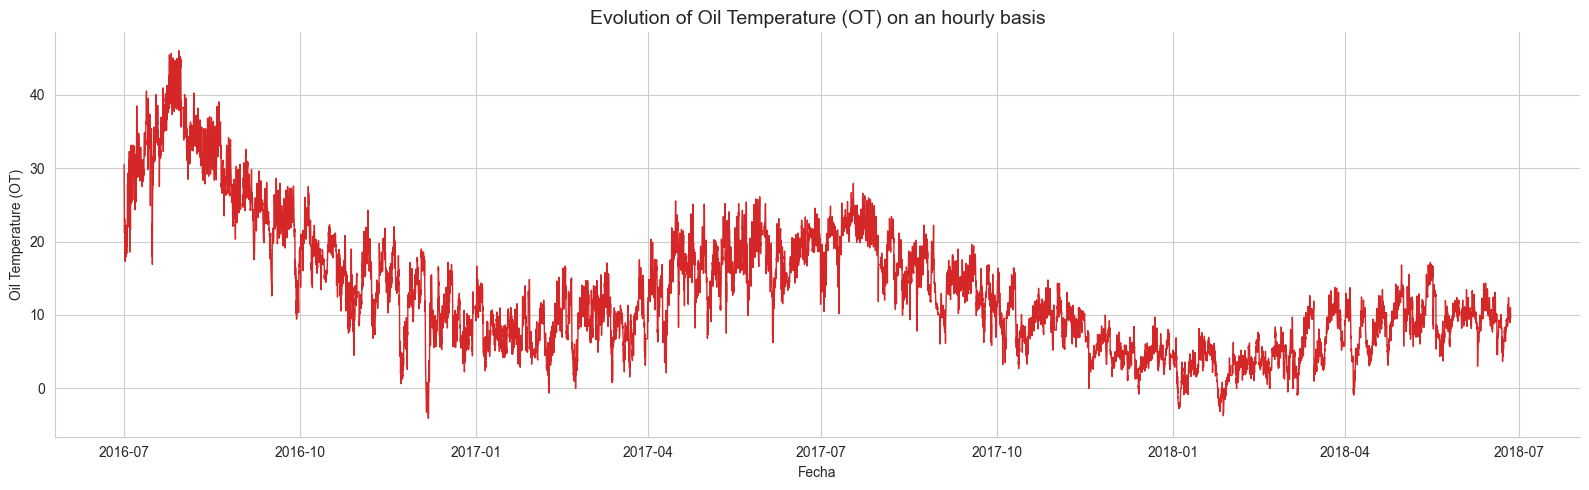

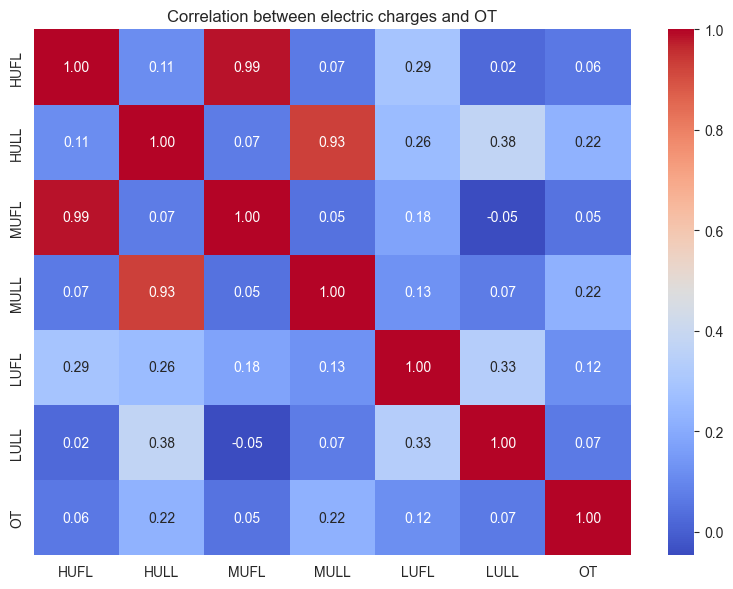

In [12]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

# Oil Temperature (OT) plot over time
plt.figure(figsize=(16, 5))
plt.plot(data.index, data['OT'], color='#d62728', linewidth=1)
plt.title('Evolution of Oil Temperature (OT) on an hourly basis', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Oil Temperature (OT)')
sns.despine()
plt.tight_layout()
plt.show()

# Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation between electric charges and OT', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering and Preprocessing
We extract features from the date (month, day, time) and scale the numerical variables for neural network training.

In [ ]:
# Extraction of temporal components to capture seasonality
data['month'] = data.index.month
data['day'] = data.index.day
data['hour'] = data.index.hour

# Predictor variables and Target
target_col = 'OT'
# Since oil temperature has strong autocorrelation, we include OT in the features because, in a time series, the target depends on its own history. 
# The trick is that the model never sees the future value of OT during training, only its past values.
feature_cols = data.columns.drop("date").tolist()

# Separation in Train (70%), Val (10%), Test (20%)
n = len(data)
train_size = int(n * 0.7)
val_size = int(n * 0.1)

train_data = data.iloc[:train_size]
val_data = data.iloc[train_size:train_size+val_size]
test_data = data.iloc[train_size+val_size:]

# Scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

train_X = scaler_X.fit_transform(train_data[feature_cols])
val_X = scaler_X.transform(val_data[feature_cols])
test_X = scaler_X.transform(test_data[feature_cols])

train_y = scaler_y.fit_transform(train_data[[target_col]])
val_y = scaler_y.transform(val_data[[target_col]])
test_y = scaler_y.transform(test_data[[target_col]])

print("Preprocessing Completed.")

Preprocessing Completed.


---
## 5. Sequence Generation (Sliding Windows)
We transform the series into sequences of time length `seq_length` to predict the next value (`pred_length=1`).

In [14]:
def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i + seq_length])
        ys.append(y[i + seq_length])
    return np.array(Xs), np.array(ys)

SEQ_LENGTH = 48 # We used 48 hours of history as context.

X_train_seq, y_train_seq = create_sequences(train_X, train_y, SEQ_LENGTH)
X_val_seq, y_val_seq = create_sequences(val_X, val_y, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(test_X, test_y, SEQ_LENGTH)

batch_size = 256

train_loader = DataLoader(TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32), 
                                        torch.tensor(y_train_seq, dtype=torch.float32)), 
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_seq, dtype=torch.float32), 
                                      torch.tensor(y_val_seq, dtype=torch.float32)), 
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_seq, dtype=torch.float32), 
                                       torch.tensor(y_test_seq, dtype=torch.float32)), 
                         batch_size=batch_size, shuffle=False)

print(f"Train sequences: X={X_train_seq.shape}, y={y_train_seq.shape}")

Train sequences: X=(12146, 48, 10), y=(12146, 1)


---
## 6. Modern Deep Learning Architectures
Design and implementation of 5 high-performance architectures in PyTorch adapted for time series regression.

In [ ]:
n_features = X_train_seq.shape[2] 

# Positional Encoding essential for Transformers
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: [Batch, Seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return x

# 1. LSTM with Attention (Baseline)
class LSTMAttention(nn.Module):
    def __init__(self, hidden_dim=64, n_features=n_features):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        return self.fc(context)

# 2. Vanilla Transformer 
class VanillaTransformer(nn.Module):
    def __init__(self, n_features=n_features, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model) 
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x) 
        out = self.transformer(x)
        out = out.mean(dim=1) 
        return self.fc(out)

# 3. DLinear (Decomposition Linear) 
class moving_avg(nn.Module):
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)
    def forward(self, x):
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size // 2), 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        return x.permute(0, 2, 1)

class series_decomp(nn.Module):
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)
    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean

class DLinear(nn.Module):
    def __init__(self, seq_len=SEQ_LENGTH, n_features=n_features):
        super().__init__()
        self.seq_len = seq_len
        self.decompsition = series_decomp(25)
        self.Linear_Seasonal = nn.Linear(seq_len, 1)
        self.Linear_Trend = nn.Linear(seq_len, 1)
        self.combine = nn.Linear(n_features, 1)

    def forward(self, x):
        seasonal_init, trend_init = self.decompsition(x)
        seasonal_init = seasonal_init.permute(0,2,1)
        trend_init = trend_init.permute(0,2,1)
        
        seasonal_out = self.Linear_Seasonal(seasonal_init).squeeze(-1)
        trend_out = self.Linear_Trend(trend_init).squeeze(-1)
    
        x = seasonal_out + trend_out 
        return self.combine(x) 

# 4. PatchTST (Patch Time Series Transformer)
class PatchTST(nn.Module):
    def __init__(self, seq_len=SEQ_LENGTH, patch_len=12, stride=12, n_features=n_features, d_model=64, nhead=4):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.num_patches = int((seq_len - patch_len) / stride + 1)
        
        self.patch_proj = nn.Linear(patch_len * n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model) 
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        patches = x.unfold(dimension=1, size=self.patch_len, step=self.stride) 
        B, num_patches, F, P = patches.shape
        patches = patches.reshape(B, num_patches, F * P)
        
        x_t = self.patch_proj(patches)
        x_t = self.pos_encoder(x_t) 
        out = self.transformer(x_t)
        out = out.mean(dim=1)
        return self.head(out)

# 5. ConvTransformer (Híbrid)
class ConvTransformer(nn.Module):
    def __init__(self, n_features=n_features, d_model=64, nhead=4):
        super().__init__()
        self.conv = nn.Conv1d(in_channels=n_features, out_channels=d_model, kernel_size=3, padding=1)
        self.pos_encoder = PositionalEncoding(d_model) 
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = F.relu(self.conv(x))
        x = x.permute(0, 2, 1) 
        x = self.pos_encoder(x) 
        
        out = self.transformer(x)
        out = out.mean(dim=1)
        return self.fc(out)

---
## 7. Hyperparameter Optimization (Optuna)
We will apply Optuna to find the best learning rate for the **DLinear** model, keeping the search space small to be efficient.

In [ ]:
def objective(trial):
    lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
    model = DLinear().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Rapid 2-phase training to find the best initial LR
    for epoch in range(2):
        model.train()
        for x_b, y_b in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x_b.to(device)), y_b.to(device))
            loss.backward()
            optimizer.step()
            
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_b, y_b in val_loader:
            loss = criterion(model(x_b.to(device)), y_b.to(device))
            val_loss += loss.item()
            
    return val_loss / len(val_loader)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=3, show_progress_bar=True) # Restricted to 3 for speed on the notebook
best_lr = study.best_params['lr']
print(f"\nBest Learning Rate (LR) found: {best_lr:.5f}")

[I 2026-06-23 20:38:03,101] A new study created in memory with name: no-name-a3e942ea-a233-4082-b891-54197f01d169
[I 2026-06-23 20:38:03,722] Trial 0 finished with value: 1.7769508872713362 and parameters: {'lr': 0.0008385665425781053}. Best is trial 0 with value: 1.7769508872713362.
[I 2026-06-23 20:38:04,200] Trial 1 finished with value: 0.038381200815950124 and parameters: {'lr': 0.0040285001812932165}. Best is trial 1 with value: 0.038381200815950124.
[I 2026-06-23 20:38:04,688] Trial 2 finished with value: 0.7930581995419094 and parameters: {'lr': 0.0003305135579866206}. Best is trial 1 with value: 0.038381200815950124.



Best Learning Rate (LR) found: 0.00403


---
## 8. Benchmark Training Loop
We evaluated all models. We implemented regression metric control (MSE, MAE) and time per epoch.

In [ ]:
def train_evaluate_regression(model, name, train_loader, val_loader, epochs=25, lr=best_lr, patience=5):
    print(f"\n{'='*40}\nTraining: {name}\n{'='*40}")    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    no_improve = 0
    best_state = None
    start_time = time.time()

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            preds = model(x_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_mean = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                preds = model(x_b)
                loss = criterion(preds, y_b)
                val_loss += loss.item()

        val_mean = val_loss / len(val_loader)

        # Early Stopping Logic
        if val_mean < best_val_loss:
            best_val_loss, no_improve = val_mean, 0
            best_state = model.state_dict()
            estado = "Saved"
        else:
            no_improve += 1
            estado = ""

        print(f"Epoch {epoch:2d} | Train MSE Loss: {train_mean:.4f} | Val MSE Loss: {val_mean:.4f} {estado}")

        if no_improve >= patience:
            print(f"Early stopping activated during the season {epoch}")
            break

    execution_time = time.time() - start_time
    model.load_state_dict(best_state)
    
    return model, execution_time

# Standardized inference function extracting predictions and probabilities.
def test_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            preds = model(x_b.to(device))
            y_true.extend(y_b.numpy())
            y_pred.extend(preds.cpu().numpy())

    # Return to original scale for interpretable metrics
    y_true_unscaled = scaler_y.inverse_transform(np.array(y_true).reshape(-1, 1))
    y_pred_unscaled = scaler_y.inverse_transform(np.array(y_pred).reshape(-1, 1))

    return y_true_unscaled, y_pred_unscaled


# Initialize Models
models = {
    "LSTM-Attention": LSTMAttention().to(device),
    "Vanilla Transformer": VanillaTransformer().to(device),
    "PatchTST": PatchTST().to(device),
    "DLinear": DLinear().to(device),
    "ConvTransformer": ConvTransformer().to(device)
}

# Run Benchmark
benchmark_results = []
predictions_dict = {}

for name, model in models.items():
    trained_model, exec_time = train_evaluate_regression(model, name, train_loader, val_loader)
    y_true, y_pred = test_model(trained_model, test_loader)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    benchmark_results.append({
        'Model': name,
        'MSE': mse,
        'MAE': mae,
        'R2 Score': r2,
        'Time (s)': exec_time
    })

    predictions_dict[name] = {'y_true': y_true, 'y_pred': y_pred}

df_results = pd.DataFrame(benchmark_results)


Training: LSTM-Attention
Epoch  0 | Train MSE Loss: 0.2237 | Val MSE Loss: 0.1929 Saved
Epoch  1 | Train MSE Loss: 0.0790 | Val MSE Loss: 0.1799 Saved
Epoch  2 | Train MSE Loss: 0.0310 | Val MSE Loss: 0.0288 Saved
Epoch  3 | Train MSE Loss: 0.0184 | Val MSE Loss: 0.0153 Saved
Epoch  4 | Train MSE Loss: 0.0161 | Val MSE Loss: 0.0122 Saved
Epoch  5 | Train MSE Loss: 0.0150 | Val MSE Loss: 0.0093 Saved
Epoch  6 | Train MSE Loss: 0.0146 | Val MSE Loss: 0.0104 
Epoch  7 | Train MSE Loss: 0.0145 | Val MSE Loss: 0.0159 
Epoch  8 | Train MSE Loss: 0.0143 | Val MSE Loss: 0.0086 Saved
Epoch  9 | Train MSE Loss: 0.0139 | Val MSE Loss: 0.0100 
Epoch 10 | Train MSE Loss: 0.0136 | Val MSE Loss: 0.0102 
Epoch 11 | Train MSE Loss: 0.0136 | Val MSE Loss: 0.0106 
Epoch 12 | Train MSE Loss: 0.0140 | Val MSE Loss: 0.0069 Saved
Epoch 13 | Train MSE Loss: 0.0139 | Val MSE Loss: 0.0087 
Epoch 14 | Train MSE Loss: 0.0134 | Val MSE Loss: 0.0135 
Epoch 15 | Train MSE Loss: 0.0133 | Val MSE Loss: 0.0115 
Epoch 

---
## 9. Results and Comparative Graphs
We compare computational efficiency (Time) and accuracy (MAE, MSE). Finally, we visualize the predictions against the actual values.

,Model,MSE,MAE,R2 Score,Time (s)
3,DLinear,0.450096,0.469454,0.961430,6.433779
0,LSTM-Attention,0.631553,0.572345,0.945880,12.641315
1,Vanilla Transformer,0.736541,0.645975,0.936883,16.294306
2,PatchTST,0.878877,0.728843,0.924686,7.244189
4,ConvTransformer,2.043384,1.194897,0.824895,24.029426


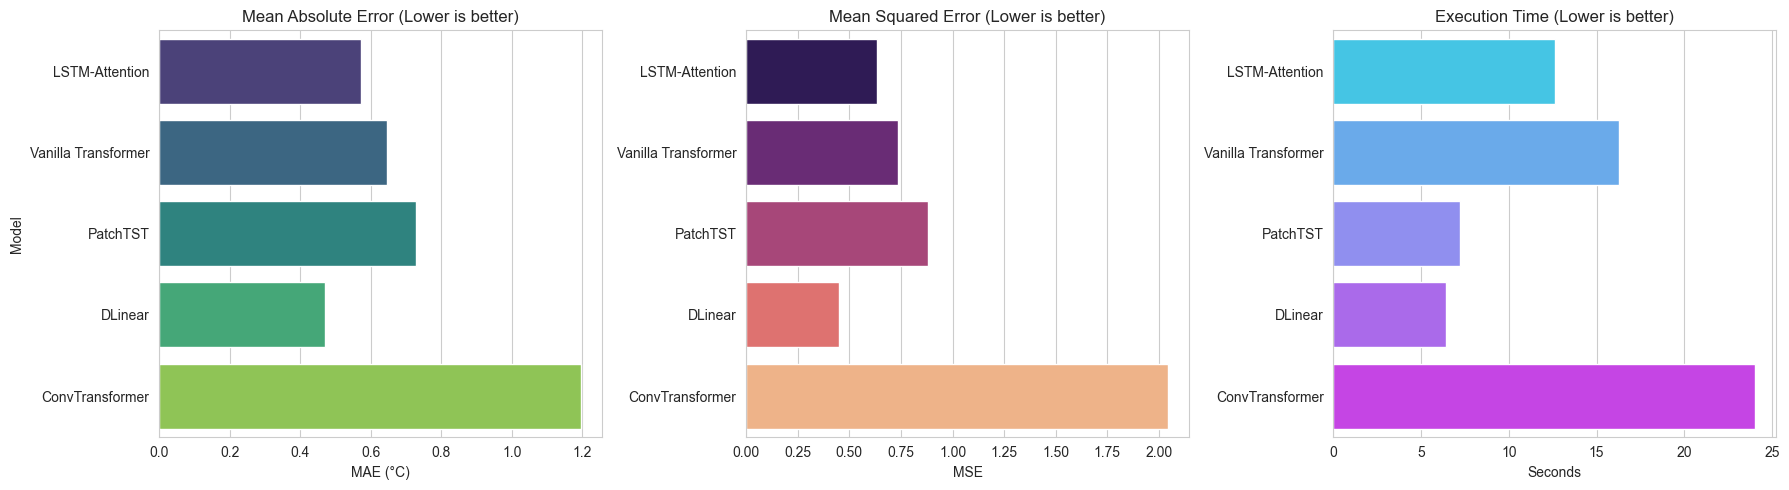

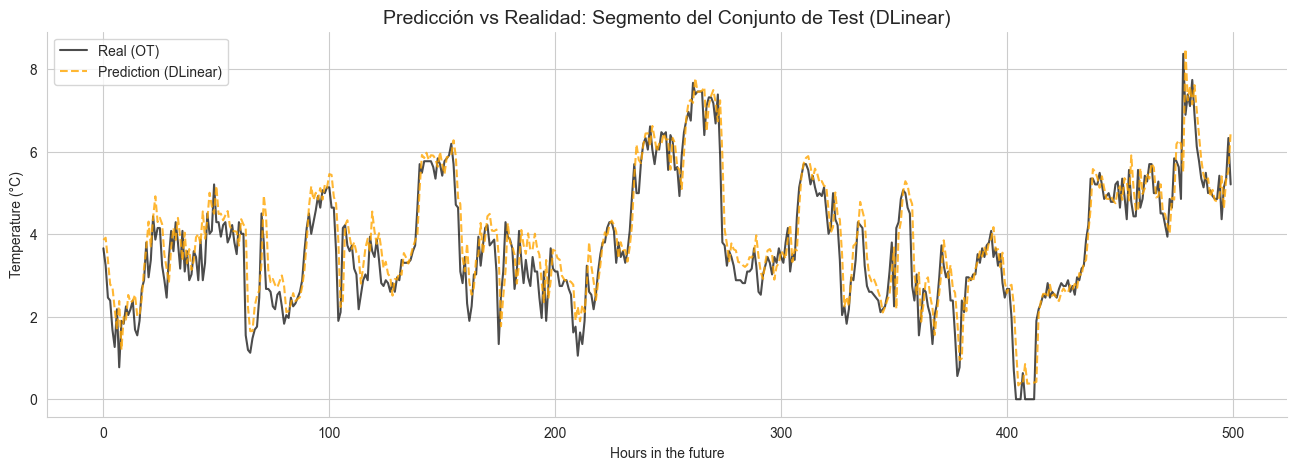

In [19]:
display(df_results.sort_values(by='MAE'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_style('whitegrid')

# Plot MAE
sns.barplot(data=df_results, x='MAE', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('Mean Absolute Error (Lower is better)')
axes[0].set_xlabel('MAE (°C)')

# Plot MSE
sns.barplot(data=df_results, x='MSE', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('Mean Squared Error (Lower is better)')
axes[1].set_xlabel('MSE')
axes[1].set_ylabel('')

# Plot Time
sns.barplot(data=df_results, x='Time (s)', y='Model', palette='cool', ax=axes[2])
axes[2].set_title('Execution Time (Lower is better)')
axes[2].set_xlabel('Seconds')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# Time Series Forecast Visualization (Best Model)
best_model = df_results.loc[df_results['MAE'].idxmin(), 'Model']
best_y_pred = predictions_dict[best_model]['y_pred']

# We take a segment to visualize clearly (e.g. 500 hours)
segment = 500
plt.figure(figsize=(16, 5))
plt.plot(y_true[:segment], label='Real (OT)', color='black', alpha=0.7)
plt.plot(best_y_pred[:segment], label=f'Prediction ({best_model})', color='orange', alpha=0.8, linestyle='--')
plt.title(f'Predicción vs Realidad: Segmento del Conjunto de Test ({best_model})', fontsize=14)
plt.xlabel('Hours in the future')
plt.ylabel('Temperature (°C)')
plt.legend()
sns.despine()
plt.show()